# Estudio de caída de consumo

Segundo notebook de la fase de segmentación. Lee la salida del agrupamiento
(`clientes_clusters_consumo.parquet`) y determina qué clientes han bajado su
consumo de forma significativa.

## Diseño

**Ventana según la periodicidad de lectura.** Los clientes con lectura mensual
se evalúan sobre los **últimos 3 meses**; los de lectura trimestral (rurales)
sobre los **últimos 6 meses**, porque con lecturas cada 3 meses una ventana de
3 contiene una sola lectura real repartida por la reconstrucción, y cualquier
variación medida ahí es un artefacto del reparto, no una señal.

**Dos comparaciones, no una.**
- *Periodo anterior*: la ventana reciente contra la ventana inmediatamente
  previa. Detecta la caída que empezó hace poco.
- *Año contra año*: la ventana reciente contra el mismo periodo calendario del
  año anterior. Descuenta la estacionalidad.

Un cliente que cae en ambas es una caída real y sostenida. Uno que cae solo
contra el periodo anterior puede ser estacionalidad. Uno que cae solo contra
el año pasado viene bajando desde antes, sin agravarse ahora. Los tres casos
significan cosas distintas para el negocio, así que se reportan por separado.

**El umbral es relativo a su segmento, no global.** Una caída del 15% en
`URBANO_BASE_ESTABLE` (cuyos clientes varían casi nada) es una anomalía seria;
la misma caída en `RURAL_INTERMITENTE_CRITICO` es ruido normal. Por eso cada
cliente se compara contra la distribución de variación de **su propio
segmento**, usando una escala robusta (IQR), y no contra un número fijo para
todos.

A eso se le suma un piso de negocio: por muy anómala que sea estadísticamente,
una caída menor al umbral mínimo absoluto no se reporta, para no llenar la
lista de casos irrelevantes.

## Salida

- `estudio_caida_consumo.parquet` — un registro por NIU con las dos variaciones,
  su z robusto dentro del segmento, el veredicto y la severidad.
- `resumen_caida_por_segmento.csv` — tabla para negocio.
- `clientes_caida_prioritarios.csv` — la lista accionable, ordenada.


In [1]:
# ============================================================
# 1. LIBRERÍAS Y RUTAS
# ============================================================

from pathlib import Path
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

BASE_DIR = Path(r"C:\Users\Home\Documents\Datos Ebsa")

PREPROC_DIR = BASE_DIR / "Serie_tiempo_consumo" / "preprocesamiento_modelo"
AGRUP_DIR = BASE_DIR / "Serie_tiempo_consumo" / "agrupamiento_clientes"

CAIDA_DIR = BASE_DIR / "Serie_tiempo_consumo" / "estudio_caida"
CAIDA_DIR.mkdir(parents=True, exist_ok=True)

RUTA_SERIE = PREPROC_DIR / "serie_mensual_modelado_preprocesada.parquet"
RUTA_CLUSTERS = AGRUP_DIR / "clientes_clusters_consumo.parquet"

RUTA_CAIDA = CAIDA_DIR / "estudio_caida_consumo.parquet"
RUTA_RESUMEN_SEGMENTO = CAIDA_DIR / "resumen_caida_por_segmento.csv"
RUTA_PRIORITARIOS = CAIDA_DIR / "clientes_caida_prioritarios.csv"
RUTA_DIAGNOSTICO_BORDE = CAIDA_DIR / "diagnostico_borde_ventana.csv"

# --- Ventanas de evaluación ---
MESES_VENTANA_MENSUAL = 3      # clientes con lectura mensual
MESES_VENTANA_TRIMESTRAL = 6   # clientes con lectura trimestral (rurales)

# --- Umbrales ---
# Estadístico: cuántas escalas robustas por debajo de la mediana de SU segmento
K_DESVIACIONES = 2.0
# Piso de negocio: por anómala que sea, una caída menor a esto no se reporta
UMBRAL_MINIMO_CAIDA_PCT = -10.0
UMBRAL_CAIDA_FUERTE_PCT = -30.0
UMBRAL_CAIDA_CRITICA_PCT = -50.0

# Mínimo de meses con dato en cada ventana para que la comparación sea válida
def minimo_validos(n_meses):
    return max(2, int(np.ceil(n_meses * 0.6)))

SEED = 42

print("Serie      :", RUTA_SERIE)
print("Segmentos  :", RUTA_CLUSTERS)
print("Salidas    :", CAIDA_DIR)
print()
print(f"Ventana mensual    : {MESES_VENTANA_MENSUAL} meses "
      f"(mínimo {minimo_validos(MESES_VENTANA_MENSUAL)} con dato)")
print(f"Ventana trimestral : {MESES_VENTANA_TRIMESTRAL} meses "
      f"(mínimo {minimo_validos(MESES_VENTANA_TRIMESTRAL)} con dato)")


Serie      : C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\preprocesamiento_modelo\serie_mensual_modelado_preprocesada.parquet
Segmentos  : C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\agrupamiento_clientes\clientes_clusters_consumo.parquet
Salidas    : C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\estudio_caida

Ventana mensual    : 3 meses (mínimo 2 con dato)
Ventana trimestral : 6 meses (mínimo 4 con dato)


## Cargar segmentos y serie

In [2]:
# ============================================================
# 2. CARGAR LA SEGMENTACIÓN Y LA SERIE MENSUAL
# ============================================================

for ruta in (RUTA_SERIE, RUTA_CLUSTERS):
    if not ruta.exists():
        raise FileNotFoundError(f"No existe:\n{ruta}")

clusters = pd.read_parquet(RUTA_CLUSTERS, engine="pyarrow")
clusters["NIU"] = clusters["NIU"].astype("string").str.strip()

columnas_necesarias = {
    "NIU", "cluster_id", "segmento_base", "zona",
    "es_rural_final", "segmento_prioridad",
}
faltantes = columnas_necesarias - set(clusters.columns)
if faltantes:
    raise ValueError(
        f"Al parquet de segmentos le faltan columnas: {sorted(faltantes)}. "
        "Vuelve a correr el notebook de agrupamiento."
    )

serie = pd.read_parquet(
    RUTA_SERIE, columns=["NIU", "periodo", "consumo_kwh_mensual"], engine="pyarrow",
)
serie["NIU"] = serie["NIU"].astype("string").str.strip()
serie["periodo"] = pd.to_datetime(serie["periodo"], errors="coerce")
serie["consumo_kwh_mensual"] = pd.to_numeric(
    serie["consumo_kwh_mensual"], errors="coerce"
).astype("float32")

periodo_max = serie["periodo"].max().to_period("M").to_timestamp()

print("SEGMENTACIÓN")
print("-" * 60)
print(f"Clientes  : {len(clusters):,}")
print(f"Segmentos : {clusters['cluster_id'].nunique()}")

print("\nSERIE")
print("-" * 60)
print(f"Filas          : {len(serie):,}")
print(f"NIU únicos     : {serie['NIU'].nunique():,}")
print(f"Último periodo : {periodo_max:%Y-%m}")

if len(clusters) != serie["NIU"].nunique():
    print(
        f"\n⚠ La segmentación tiene {len(clusters):,} clientes y la serie "
        f"{serie['NIU'].nunique():,}. Se trabajará sobre la intersección."
    )


SEGMENTACIÓN
------------------------------------------------------------
Clientes  : 592,159
Segmentos : 15

SERIE
------------------------------------------------------------
Filas          : 26,888,751
NIU únicos     : 592,159
Último periodo : 2026-01


## Diagnóstico previo: ¿el último mes de la ventana está truncado?

Antes de medir cualquier caída hay que descartar un artefacto. Si el último mes
de la serie tiene menos clientes con lectura o un consumo medio mucho más bajo
que los anteriores, entonces **toda** la población parecerá estar cayendo, y lo
que estaríamos midiendo es el corte de los datos, no el comportamiento de los
clientes. Esto es especialmente probable en los rurales, donde la
reconstrucción trimestral reparte una lectura entre varios meses y el último
tramo puede quedar incompleto.

Si el diagnóstico muestra un desplome en el borde, la ventana reciente debe
retroceder un mes.


,zona,periodo,clientes_con_dato,pct_vs_referencia_clientes,consumo_medio_kwh,pct_vs_referencia_consumo
0,RURAL,2025-11-01,215185,100.4,52.93,102.599998
1,RURAL,2025-12-01,215187,100.4,54.65,105.900002
2,RURAL,2026-01-01,216835,101.2,24.72,47.900002
3,URBANO,2025-11-01,358369,101.4,161.81,97.400002
4,URBANO,2025-12-01,359558,101.7,159.83,96.199997
5,URBANO,2026-01-01,360525,102.0,161.09,97.000000


LECTURA DEL DIAGNÓSTICO
----------------------------------------------------------------------
⚠ Meses con cobertura o consumo anormalmente bajos:


,zona,periodo,clientes_con_dato,pct_vs_referencia_clientes,consumo_medio_kwh,pct_vs_referencia_consumo
2,RURAL,2026-01-01,216835,101.2,24.72,47.900002


Si el mes más reciente aparece aquí, considera retroceder la ventana
un mes antes de interpretar los resultados: la caída medida incluiría
el efecto del corte de datos.


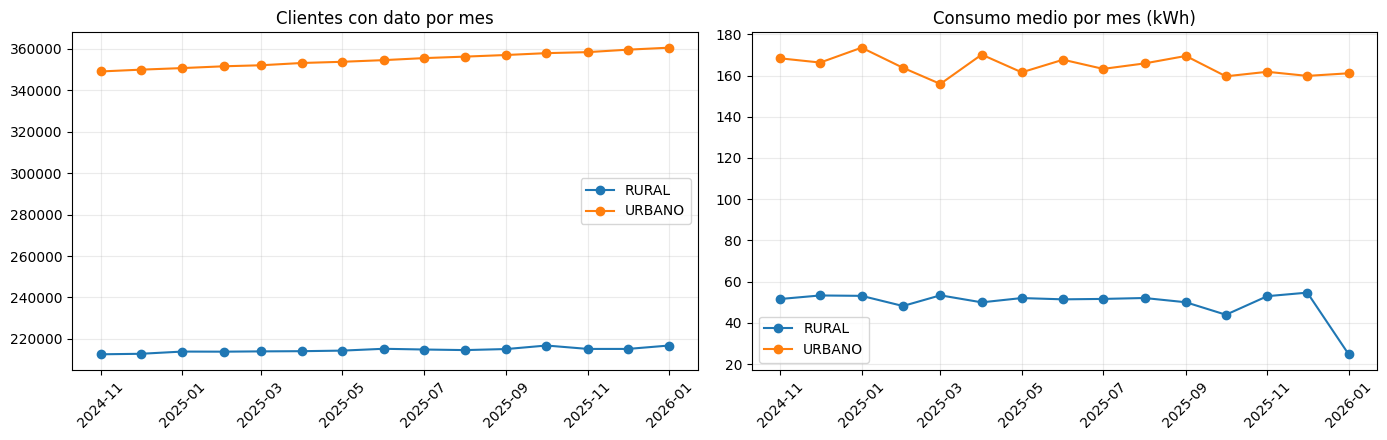

2292

In [3]:
# ============================================================
# 3. DIAGNÓSTICO DEL BORDE DE LA VENTANA
# ============================================================

meses_diag = pd.date_range(end=periodo_max, periods=15, freq="MS")

serie_diag = serie[serie["periodo"].isin(meses_diag)].merge(
    clusters[["NIU", "es_rural_final"]], on="NIU", how="inner",
)

diagnostico = (
    serie_diag
    .groupby(["es_rural_final", "periodo"])
    .agg(
        clientes_con_dato=("consumo_kwh_mensual", lambda s: int(s.notna().sum())),
        consumo_medio_kwh=("consumo_kwh_mensual", "mean"),
    )
    .reset_index()
)

diagnostico["zona"] = np.where(diagnostico["es_rural_final"], "RURAL", "URBANO")

# Comparar cada mes contra la mediana de los 12 meses previos de su zona
alertas = []
for zona, grupo in diagnostico.groupby("zona"):
    grupo = grupo.sort_values("periodo")
    referencia_clientes = grupo["clientes_con_dato"].iloc[:-3].median()
    referencia_consumo = grupo["consumo_medio_kwh"].iloc[:-3].median()

    for _, fila in grupo.tail(3).iterrows():
        pct_clientes = fila["clientes_con_dato"] / referencia_clientes * 100
        pct_consumo = fila["consumo_medio_kwh"] / referencia_consumo * 100
        alertas.append({
            "zona": zona,
            "periodo": fila["periodo"],
            "clientes_con_dato": int(fila["clientes_con_dato"]),
            "pct_vs_referencia_clientes": round(pct_clientes, 1),
            "consumo_medio_kwh": round(fila["consumo_medio_kwh"], 2),
            "pct_vs_referencia_consumo": round(pct_consumo, 1),
        })

alertas = pd.DataFrame(alertas)
display(alertas)

alertas.to_csv(RUTA_DIAGNOSTICO_BORDE, index=False, encoding="utf-8-sig")

print("LECTURA DEL DIAGNÓSTICO")
print("-" * 70)
sospechosos = alertas[
    (alertas["pct_vs_referencia_clientes"] < 90)
    | (alertas["pct_vs_referencia_consumo"] < 85)
]
if len(sospechosos):
    print("⚠ Meses con cobertura o consumo anormalmente bajos:")
    display(sospechosos)
    print(
        "Si el mes más reciente aparece aquí, considera retroceder la ventana\n"
        "un mes antes de interpretar los resultados: la caída medida incluiría\n"
        "el efecto del corte de datos."
    )
else:
    print("✓ Ningún mes reciente muestra cobertura ni consumo anormalmente bajos.")
    print("  El borde de la ventana no parece truncado.")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (columna, titulo) in zip(
    axes,
    [("clientes_con_dato", "Clientes con dato por mes"),
     ("consumo_medio_kwh", "Consumo medio por mes (kWh)")],
):
    for zona, grupo in diagnostico.groupby("zona"):
        grupo = grupo.sort_values("periodo")
        ax.plot(grupo["periodo"], grupo[columna], marker="o", label=zona)
    ax.set_title(titulo)
    ax.grid(alpha=0.25)
    ax.legend()
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

del serie_diag
gc.collect()


## Construir las ventanas de comparación

In [4]:
# ============================================================
# 4. MATRIZ NIU x MES (24 meses, suficiente para las tres ventanas)
# ============================================================

meses_matriz = pd.date_range(end=periodo_max, periods=24, freq="MS")

todos_los_niu = pd.Index(
    clusters["NIU"].astype("string").unique(), name="NIU"
).sort_values()

wide = (
    serie[serie["periodo"].isin(meses_matriz)]
    [["NIU", "periodo", "consumo_kwh_mensual"]]
    .pivot(index="NIU", columns="periodo", values="consumo_kwh_mensual")
    .reindex(index=todos_los_niu, columns=meses_matriz)
    .astype("float32")
)

nius = wide.index.astype("string").to_numpy()
matriz = wide.to_numpy(dtype="float32", copy=False)
indice_mes = {mes: i for i, mes in enumerate(meses_matriz)}

print(f"Matriz: {matriz.shape[0]:,} clientes x {matriz.shape[1]} meses")
print(f"Rango : {meses_matriz[0]:%Y-%m} → {meses_matriz[-1]:%Y-%m}")

del wide
gc.collect()


Matriz: 592,159 clientes x 24 meses
Rango : 2024-02 → 2026-01


0

In [5]:
# ============================================================
# 5. DEFINIR LAS TRES VENTANAS POR PERIODICIDAD
# ============================================================

def ventana(n_meses, offset_meses):
    """n_meses terminando `offset_meses` antes del último periodo."""
    fin = periodo_max - pd.DateOffset(months=offset_meses)
    return pd.date_range(end=fin, periods=n_meses, freq="MS")


VENTANAS = {}

for etiqueta, n in [
    ("MENSUAL", MESES_VENTANA_MENSUAL),
    ("TRIMESTRAL", MESES_VENTANA_TRIMESTRAL),
]:
    VENTANAS[etiqueta] = {
        "n_meses": n,
        "reciente": ventana(n, 0),
        "anterior": ventana(n, n),
        "anio_pasado": ventana(n, 12),
    }

print("VENTANAS DE COMPARACIÓN")
print("=" * 70)
for etiqueta, v in VENTANAS.items():
    print(f"\n{etiqueta} ({v['n_meses']} meses)")
    for nombre in ["reciente", "anterior", "anio_pasado"]:
        rango = v[nombre]
        print(f"  {nombre:<12}: {rango[0]:%Y-%m} → {rango[-1]:%Y-%m}")

# Verificar que todas las ventanas caben en la matriz
for etiqueta, v in VENTANAS.items():
    for nombre in ["reciente", "anterior", "anio_pasado"]:
        faltan = [m for m in v[nombre] if m not in indice_mes]
        if faltan:
            raise ValueError(
                f"La ventana {nombre} de {etiqueta} necesita meses fuera de la "
                f"matriz: {[f'{m:%Y-%m}' for m in faltan]}"
            )
print("\n✓ Todas las ventanas caben en la matriz de 24 meses.")


VENTANAS DE COMPARACIÓN

MENSUAL (3 meses)
  reciente    : 2025-11 → 2026-01
  anterior    : 2025-08 → 2025-10
  anio_pasado : 2024-11 → 2025-01

TRIMESTRAL (6 meses)
  reciente    : 2025-08 → 2026-01
  anterior    : 2025-02 → 2025-07
  anio_pasado : 2024-08 → 2025-01

✓ Todas las ventanas caben en la matriz de 24 meses.


In [6]:
# ============================================================
# 6. CONSUMO PROMEDIO POR VENTANA
# ============================================================
# Se usa el promedio de los meses CON dato, no la suma: si a un cliente le
# falta un mes, la suma lo castigaría como si hubiera consumido cero.
# ============================================================

def promedio_ventana(meses, min_validos):
    cols = [indice_mes[m] for m in meses]
    sub = matriz[:, cols]

    validos = (~np.isnan(sub)).sum(axis=1)

    with np.errstate(invalid="ignore"):
        promedio = np.nanmean(sub, axis=1).astype("float64")

    promedio[validos < min_validos] = np.nan
    return promedio, validos


# La periodicidad decide qué ventana aplica a cada cliente
es_rural = (
    clusters.set_index("NIU")["es_rural_final"]
    .reindex(nius)
    .fillna(False)
    .to_numpy(dtype=bool)
)

n_clientes = len(nius)
promedios = {
    nombre: np.full(n_clientes, np.nan, dtype="float64")
    for nombre in ["reciente", "anterior", "anio_pasado"]
}
meses_validos = {
    nombre: np.zeros(n_clientes, dtype="int16")
    for nombre in ["reciente", "anterior", "anio_pasado"]
}
n_meses_cliente = np.where(es_rural, MESES_VENTANA_TRIMESTRAL, MESES_VENTANA_MENSUAL)

for etiqueta, mascara in [("MENSUAL", ~es_rural), ("TRIMESTRAL", es_rural)]:
    v = VENTANAS[etiqueta]
    minimo = minimo_validos(v["n_meses"])

    for nombre in ["reciente", "anterior", "anio_pasado"]:
        prom, val = promedio_ventana(v[nombre], minimo)
        promedios[nombre][mascara] = prom[mascara]
        meses_validos[nombre][mascara] = val[mascara]

print("COBERTURA DE LAS VENTANAS")
print("-" * 70)
for nombre in ["reciente", "anterior", "anio_pasado"]:
    n_ok = int(np.isfinite(promedios[nombre]).sum())
    print(
        f"  {nombre:<12}: {n_ok:,} clientes con promedio válido "
        f"({n_ok / n_clientes * 100:.1f}%)"
    )


COBERTURA DE LAS VENTANAS
----------------------------------------------------------------------
  reciente    : 574,548 clientes con promedio válido (97.0%)
  anterior    : 570,907 clientes con promedio válido (96.4%)
  anio_pasado : 562,310 clientes con promedio válido (95.0%)


C:\Users\Home\AppData\Local\Temp\ipykernel_21588\3299647157.py:15: RuntimeWarning: Mean of empty slice
  promedio = np.nanmean(sub, axis=1).astype("float64")


## Variaciones y umbral relativo al segmento

In [7]:
# ============================================================
# 7. VARIACIÓN PORCENTUAL EN LAS DOS COMPARACIONES
# ============================================================

def variacion_pct(reciente, referencia):
    """% de cambio del promedio reciente frente a una referencia.
    Devuelve NaN si la referencia es 0 o falta algún dato: no se puede
    hablar de caída porcentual desde cero."""
    salida = np.full(len(reciente), np.nan, dtype="float64")
    valido = (
        np.isfinite(reciente) & np.isfinite(referencia) & (referencia > 0)
    )
    salida[valido] = (
        (reciente[valido] - referencia[valido]) / referencia[valido] * 100
    )
    return salida


var_vs_anterior = variacion_pct(promedios["reciente"], promedios["anterior"])
var_vs_anio = variacion_pct(promedios["reciente"], promedios["anio_pasado"])

caida = pd.DataFrame({
    "NIU": nius,
    "meses_ventana": n_meses_cliente.astype("int16"),
    "consumo_reciente_kwh": promedios["reciente"],
    "consumo_anterior_kwh": promedios["anterior"],
    "consumo_anio_pasado_kwh": promedios["anio_pasado"],
    "meses_validos_reciente": meses_validos["reciente"],
    "meses_validos_anterior": meses_validos["anterior"],
    "meses_validos_anio_pasado": meses_validos["anio_pasado"],
    "variacion_vs_anterior_pct": var_vs_anterior,
    "variacion_vs_anio_pct": var_vs_anio,
})

caida = caida.merge(
    clusters[[
        "NIU", "cluster_id", "segmento_base", "zona",
        "es_rural_final", "segmento_prioridad",
    ]],
    on="NIU", how="left",
)

print("VARIACIONES CALCULADAS")
print("-" * 70)
print(f"  vs. periodo anterior : {int(caida['variacion_vs_anterior_pct'].notna().sum()):,}")
print(f"  vs. año pasado       : {int(caida['variacion_vs_anio_pct'].notna().sum()):,}")

display(
    caida[["variacion_vs_anterior_pct", "variacion_vs_anio_pct"]]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .T
)


VARIACIONES CALCULADAS
----------------------------------------------------------------------
  vs. periodo anterior : 535,530
  vs. año pasado       : 528,408


,count,mean,std,min,5%,25%,50%,75%,95%,max
variacion_vs_anterior_pct,535530.0,44.956195,1319.883947,-100.0,-66.666666,-17.419998,-2.919706,11.080889,114.222569,414299.999857
variacion_vs_anio_pct,528408.0,114.695655,2688.411736,-100.0,-85.520713,-25.371892,-5.496676,15.878746,199.612778,940549.971966


In [8]:
# ============================================================
# 8. UMBRAL RELATIVO A CADA SEGMENTO (ESCALA ROBUSTA)
# ============================================================
# Un mismo % de caída significa cosas distintas según el segmento. Se compara
# a cada cliente contra la distribución de SU segmento usando el IQR como
# escala: la desviación estándar la destrozan las colas, el IQR no.
# ============================================================

SEGMENTOS_SIN_EVALUAR = {"SIN_CONSUMO", "NUEVO_O_SIN_DATOS"}


def escala_robusta_por_segmento(df, columna, columna_segmento="cluster_id"):
    """Devuelve mediana y escala robusta (IQR/1.349) por segmento.
    Si el IQR es cero (segmento muy homogéneo), cae a la desviación estándar."""

    stats = (
        df.groupby(columna_segmento)[columna]
        .agg(
            mediana="median",
            q25=lambda s: s.quantile(0.25),
            q75=lambda s: s.quantile(0.75),
            desv="std",
            n="count",
        )
    )

    stats["escala"] = (stats["q75"] - stats["q25"]) / 1.349

    sin_iqr = stats["escala"] <= 0
    stats.loc[sin_iqr, "escala"] = stats.loc[sin_iqr, "desv"]

    # Piso: evita z infinitos en segmentos degenerados
    stats["escala"] = stats["escala"].fillna(0).clip(lower=0.5)

    return stats


def z_robusto(df, columna, columna_segmento="cluster_id"):
    evaluables = df[~df["segmento_base"].isin(SEGMENTOS_SIN_EVALUAR)]
    stats = escala_robusta_por_segmento(evaluables, columna, columna_segmento)

    mediana = df[columna_segmento].map(stats["mediana"])
    escala = df[columna_segmento].map(stats["escala"])

    return (df[columna] - mediana) / escala, stats


caida["z_vs_anterior"], stats_anterior = z_robusto(caida, "variacion_vs_anterior_pct")
caida["z_vs_anio"], stats_anio = z_robusto(caida, "variacion_vs_anio_pct")

print("UMBRAL EFECTIVO POR SEGMENTO (comparación vs. periodo anterior)")
print("=" * 78)
print("El umbral es: mediana del segmento - K x escala robusta")
print(f"K = {K_DESVIACIONES}, con piso de negocio en {UMBRAL_MINIMO_CAIDA_PCT:.0f}%\n")

tabla_umbrales = stats_anterior[["n", "mediana", "escala"]].copy()
tabla_umbrales["umbral_estadistico_pct"] = (
    tabla_umbrales["mediana"] - K_DESVIACIONES * tabla_umbrales["escala"]
).round(2)
tabla_umbrales["umbral_aplicado_pct"] = np.minimum(
    tabla_umbrales["umbral_estadistico_pct"], UMBRAL_MINIMO_CAIDA_PCT
).round(2)
tabla_umbrales = tabla_umbrales.round(2).sort_values("umbral_aplicado_pct")

display(tabla_umbrales)

print(
    "\nLéase así: en un segmento estable el umbral se acerca al piso de "
    f"{UMBRAL_MINIMO_CAIDA_PCT:.0f}%,\nmientras que en uno volátil hace falta "
    "una caída mucho mayor para destacar."
)


UMBRAL EFECTIVO POR SEGMENTO (comparación vs. periodo anterior)
El umbral es: mediana del segmento - K x escala robusta
K = 2.0, con piso de negocio en -10%



,n,mediana,escala,umbral_estadistico_pct,umbral_aplicado_pct
cluster_id,,,,,
RURAL_EN_REACTIVACION,1656,1000.00,1830.06,-2660.11,-2660.11
URBANO_EN_REACTIVACION,5063,267.03,589.05,-911.06,-911.06
URBANO_CAIDA_SEVERA,5748,0.00,123.55,-247.10,-247.10
RURAL_INTERMITENTE_CRITICO,3180,-97.87,5.53,-108.93,-108.93
RURAL_BASE_EN_DESCENSO_BAJO,84543,-13.42,47.08,-107.59,-107.59
URBANO_BASE_ESTABLE_BAJO,46665,0.00,44.50,-89.00,-89.00
RURAL_BASE_EN_DESCENSO_GRANDE,2419,-11.65,16.71,-45.08,-45.08
RURAL_BASE_EN_DESCENSO_MEDIO,81730,-11.53,14.77,-41.07,-41.07
RURAL_BASE_EN_DESCENSO_ALTO,21393,-11.25,13.29,-37.84,-37.84



Léase así: en un segmento estable el umbral se acerca al piso de -10%,
mientras que en uno volátil hace falta una caída mucho mayor para destacar.


In [9]:
# ============================================================
# 9. CLASIFICAR LA CAÍDA
# ============================================================

def marcar_caida(df, columna_variacion, columna_z):
    """Marca caída cuando se cumplen LAS DOS condiciones:
    anómala dentro de su segmento Y por debajo del piso de negocio."""
    return (
        (df[columna_z] <= -K_DESVIACIONES)
        & (df[columna_variacion] <= UMBRAL_MINIMO_CAIDA_PCT)
    )


caida["cae_vs_anterior"] = marcar_caida(
    caida, "variacion_vs_anterior_pct", "z_vs_anterior"
)
caida["cae_vs_anio"] = marcar_caida(
    caida, "variacion_vs_anio_pct", "z_vs_anio"
)

# Los segmentos no evaluables nunca se marcan
no_evaluable = caida["segmento_base"].isin(SEGMENTOS_SIN_EVALUAR)
caida.loc[no_evaluable, ["cae_vs_anterior", "cae_vs_anio"]] = False

# --- Veredicto combinado ---
sin_datos = (
    caida["variacion_vs_anterior_pct"].isna()
    & caida["variacion_vs_anio_pct"].isna()
)

condiciones = [
    no_evaluable,
    sin_datos,
    caida["cae_vs_anterior"] & caida["cae_vs_anio"],
    caida["cae_vs_anterior"],
    caida["cae_vs_anio"],
]
resultados = [
    "NO_APLICA",
    "SIN_BASE_COMPARABLE",
    "CAIDA_CONFIRMADA",
    "CAIDA_RECIENTE",
    "CAIDA_SOSTENIDA",
]
caida["veredicto"] = np.select(condiciones, resultados, default="SIN_CAIDA")

# --- Severidad: por la magnitud de la peor de las dos caídas ---
peor_caida = caida[["variacion_vs_anterior_pct", "variacion_vs_anio_pct"]].min(axis=1)
caida["caida_pct"] = peor_caida

tiene_caida = caida["veredicto"].isin(
    ["CAIDA_CONFIRMADA", "CAIDA_RECIENTE", "CAIDA_SOSTENIDA"]
)

caida["severidad"] = np.select(
    [
        tiene_caida & (peor_caida <= UMBRAL_CAIDA_CRITICA_PCT),
        tiene_caida & (peor_caida <= UMBRAL_CAIDA_FUERTE_PCT),
        tiene_caida,
    ],
    ["CRITICA", "FUERTE", "MODERADA"],
    default="NINGUNA",
)

print("VEREDICTO")
print("=" * 70)
resumen_veredicto = (
    caida["veredicto"].value_counts().rename("n_clientes").to_frame()
)
resumen_veredicto["pct"] = (
    resumen_veredicto["n_clientes"] / len(caida) * 100
).round(2)
display(resumen_veredicto)

print("\nSEVERIDAD (solo clientes con caída)")
print("-" * 70)
display(
    caida.loc[tiene_caida, "severidad"]
    .value_counts()
    .rename("n_clientes")
    .to_frame()
)

print("\nSIGNIFICADO DE CADA VEREDICTO")
print("-" * 70)
print("  CAIDA_CONFIRMADA    : cae contra el periodo anterior Y contra el año")
print("                        pasado. Señal más fuerte, no es estacionalidad.")
print("  CAIDA_RECIENTE      : solo contra el periodo anterior. Empezó hace poco,")
print("                        o puede ser efecto estacional. Vigilar.")
print("  CAIDA_SOSTENIDA     : solo contra el año pasado. Viene bajando desde")
print("                        antes, sin agravarse en los últimos meses.")
print("  SIN_CAIDA           : dentro de lo normal para su segmento.")
print("  SIN_BASE_COMPARABLE : sin historia suficiente en las ventanas.")
print("  NO_APLICA           : ya estaba en cero, o sin historia (no hay de qué caer).")


VEREDICTO


,n_clientes,pct
veredicto,,
SIN_CAIDA,502067,84.79
NO_APLICA,46630,7.87
CAIDA_RECIENTE,19902,3.36
CAIDA_CONFIRMADA,11203,1.89
CAIDA_SOSTENIDA,7257,1.23
SIN_BASE_COMPARABLE,5100,0.86



SEVERIDAD (solo clientes con caída)
----------------------------------------------------------------------


,n_clientes
severidad,
CRITICA,24145
FUERTE,12711
MODERADA,1506



SIGNIFICADO DE CADA VEREDICTO
----------------------------------------------------------------------
  CAIDA_CONFIRMADA    : cae contra el periodo anterior Y contra el año
                        pasado. Señal más fuerte, no es estacionalidad.
  CAIDA_RECIENTE      : solo contra el periodo anterior. Empezó hace poco,
                        o puede ser efecto estacional. Vigilar.
  CAIDA_SOSTENIDA     : solo contra el año pasado. Viene bajando desde
                        antes, sin agravarse en los últimos meses.
  SIN_CAIDA           : dentro de lo normal para su segmento.
  SIN_BASE_COMPARABLE : sin historia suficiente en las ventanas.
  NO_APLICA           : ya estaba en cero, o sin historia (no hay de qué caer).


## Consolidar, resumir y priorizar

In [10]:
# ============================================================
# 10. GUARDAR EL DETALLE POR CLIENTE
# ============================================================

columnas_salida = [
    "NIU", "cluster_id", "segmento_base", "zona", "es_rural_final",
    "meses_ventana",
    "consumo_reciente_kwh", "consumo_anterior_kwh", "consumo_anio_pasado_kwh",
    "variacion_vs_anterior_pct", "variacion_vs_anio_pct",
    "z_vs_anterior", "z_vs_anio",
    "cae_vs_anterior", "cae_vs_anio",
    "veredicto", "caida_pct", "severidad",
    "segmento_prioridad",
]

caida_salida = caida[columnas_salida].copy()
caida_salida.to_parquet(RUTA_CAIDA, index=False, engine="pyarrow")

print("Guardado:", RUTA_CAIDA)
print(f"Registros: {len(caida_salida):,}")
display(caida_salida.head(10))


Guardado: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\estudio_caida\estudio_caida_consumo.parquet
Registros: 592,159


,NIU,cluster_id,segmento_base,zona,es_rural_final,meses_ventana,consumo_reciente_kwh,consumo_anterior_kwh,consumo_anio_pasado_kwh,variacion_vs_anterior_pct,variacion_vs_anio_pct,z_vs_anterior,z_vs_anio,cae_vs_anterior,cae_vs_anio,veredicto,caida_pct,severidad,segmento_prioridad
0,1000006589,URBANO_BASE_ESTABLE_MEDIO,BASE_ESTABLE,URBANO,False,3,119.000000,23.333334,61.000000,409.999986,95.081967,24.523171,3.581059,False,False,SIN_CAIDA,95.081967,NINGUNA,5
1,1000007366,URBANO_BASE_ESTABLE_MEDIO,BASE_ESTABLE,URBANO,False,3,81.333336,82.666664,62.666668,-1.612897,29.787235,-0.144604,1.146146,False,False,SIN_CAIDA,-1.612897,NINGUNA,5
2,1000008143,URBANO_BASE_ESTABLE_MEDIO,BASE_ESTABLE,URBANO,False,3,57.333332,45.666668,68.000000,25.547439,-15.686276,1.483103,-0.549611,False,False,SIN_CAIDA,-15.686276,NINGUNA,5
3,100000949,RURAL_BASE_EN_DESCENSO_MEDIO,BASE_EN_DESCENSO,RURAL,True,6,36.304600,31.586206,46.554852,14.938145,-22.017580,1.792200,-0.469455,False,False,SIN_CAIDA,-22.017580,NINGUNA,3
4,1000009920,URBANO_BASE_ESTABLE_MEDIO,BASE_ESTABLE,URBANO,False,3,72.666664,73.000000,44.000000,-0.456624,65.151509,-0.075309,2.464919,False,False,SIN_CAIDA,-0.456624,NINGUNA,5
5,1000010766,URBANO_BASE_ESTABLE_MEDIO,BASE_ESTABLE,URBANO,False,3,89.666664,99.666664,113.666664,-10.033445,-21.114370,-0.649243,-0.752031,False,False,SIN_CAIDA,-21.114370,NINGUNA,5
6,100001726,RURAL_SIN_CONSUMO,SIN_CONSUMO,RURAL,True,6,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,False,False,NO_APLICA,NaN,NINGUNA,2
7,100002503,RURAL_BASE_EN_DESCENSO_BAJO,BASE_EN_DESCENSO,RURAL,True,6,13.420289,13.849374,11.563670,-3.098225,16.055620,0.219313,0.666668,False,False,SIN_CAIDA,-3.098225,NINGUNA,3
8,100003390,RURAL_BASE_EN_DESCENSO_MEDIO,BASE_EN_DESCENSO,RURAL,True,6,24.931036,32.465515,25.453085,-23.207638,-2.051024,-0.790378,0.486302,False,False,SIN_CAIDA,-23.207638,NINGUNA,3
9,100004177,RURAL_BASE_EN_DESCENSO_MEDIO,BASE_EN_DESCENSO,RURAL,True,6,41.065220,31.711935,14.889514,29.494526,175.799599,2.777708,8.999636,False,False,SIN_CAIDA,29.494526,NINGUNA,3


In [11]:
# ============================================================
# 11. RESUMEN POR SEGMENTO (TABLA PARA NEGOCIO)
# ============================================================

resumen_segmento = (
    caida
    .groupby("cluster_id")
    .agg(
        n_clientes=("NIU", "size"),
        variacion_mediana_vs_anterior=("variacion_vs_anterior_pct", "median"),
        variacion_mediana_vs_anio=("variacion_vs_anio_pct", "median"),
        n_caida_confirmada=("veredicto", lambda s: int((s == "CAIDA_CONFIRMADA").sum())),
        n_caida_reciente=("veredicto", lambda s: int((s == "CAIDA_RECIENTE").sum())),
        n_caida_sostenida=("veredicto", lambda s: int((s == "CAIDA_SOSTENIDA").sum())),
        n_critica=("severidad", lambda s: int((s == "CRITICA").sum())),
    )
    .reset_index()
)

resumen_segmento["n_con_caida"] = (
    resumen_segmento["n_caida_confirmada"]
    + resumen_segmento["n_caida_reciente"]
    + resumen_segmento["n_caida_sostenida"]
)
resumen_segmento["pct_con_caida"] = (
    resumen_segmento["n_con_caida"] / resumen_segmento["n_clientes"] * 100
).round(2)

resumen_segmento = resumen_segmento.round(2).sort_values(
    "n_con_caida", ascending=False
)

display(resumen_segmento)

resumen_segmento.to_csv(RUTA_RESUMEN_SEGMENTO, index=False, encoding="utf-8-sig")
print("\nGuardado:", RUTA_RESUMEN_SEGMENTO)

total_caida = int(resumen_segmento["n_con_caida"].sum())
total_confirmada = int(resumen_segmento["n_caida_confirmada"].sum())
print(f"\nClientes con algún tipo de caída : {total_caida:,} "
      f"({total_caida / len(caida) * 100:.1f}% de la población)")
print(f"De ellos, caída CONFIRMADA        : {total_confirmada:,}")


,cluster_id,n_clientes,variacion_mediana_vs_anterior,variacion_mediana_vs_anio,n_caida_confirmada,n_caida_reciente,n_caida_sostenida,n_critica,n_con_caida,pct_con_caida
11,URBANO_BASE_ESTABLE_MEDIO,164812,0.80,-0.95,5005,7714,3589,11066,16308,9.89
8,URBANO_BASE_ESTABLE_ALTO,98851,0.22,0.71,2877,4699,1901,3858,9477,9.59
4,RURAL_BASE_EN_DESCENSO_MEDIO,82154,-11.53,-12.21,2173,2892,1159,4747,6224,7.58
9,URBANO_BASE_ESTABLE_BAJO,53135,0.00,-8.66,0,2679,0,2679,2679,5.04
10,URBANO_BASE_ESTABLE_GRANDE,18874,0.50,0.39,658,1059,386,791,2103,11.14
1,RURAL_BASE_EN_DESCENSO_ALTO,21536,-11.25,-9.75,422,777,202,852,1401,6.51
3,RURAL_BASE_EN_DESCENSO_GRANDE,2436,-11.65,-10.32,68,82,20,152,170,6.98
6,RURAL_INTERMITENTE_CRITICO,3247,-97.87,-98.76,0,0,0,0,0,0.00
5,RURAL_EN_REACTIVACION,1738,1000.00,496.92,0,0,0,0,0,0.00
0,NUEVO_O_SIN_DATOS,20883,-36.26,-97.67,0,0,0,0,0,0.00



Guardado: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\estudio_caida\resumen_caida_por_segmento.csv

Clientes con algún tipo de caída : 38,362 (6.5% de la población)
De ellos, caída CONFIRMADA        : 11,203


In [12]:
# ============================================================
# 12. LISTA PRIORITARIA DE CLIENTES
# ============================================================
# Orden: primero la caída confirmada y crítica, dentro de segmentos que ya
# venían marcados como prioritarios en el agrupamiento.
# ============================================================

orden_veredicto = {
    "CAIDA_CONFIRMADA": 1,
    "CAIDA_SOSTENIDA": 2,
    "CAIDA_RECIENTE": 3,
}
orden_severidad = {"CRITICA": 1, "FUERTE": 2, "MODERADA": 3}

prioritarios = caida[caida["veredicto"].isin(orden_veredicto)].copy()

prioritarios["orden_veredicto"] = prioritarios["veredicto"].map(orden_veredicto)
prioritarios["orden_severidad"] = prioritarios["severidad"].map(orden_severidad)

prioritarios = prioritarios.sort_values(
    ["orden_veredicto", "orden_severidad", "caida_pct", "consumo_anterior_kwh"],
    ascending=[True, True, True, False],
)

columnas_prioritarias = [
    "NIU", "cluster_id", "zona", "veredicto", "severidad",
    "consumo_anterior_kwh", "consumo_reciente_kwh",
    "variacion_vs_anterior_pct", "variacion_vs_anio_pct",
    "meses_ventana",
]

prioritarios[columnas_prioritarias].to_csv(
    RUTA_PRIORITARIOS, index=False, encoding="utf-8-sig",
)

print(f"Clientes en la lista prioritaria: {len(prioritarios):,}")
print("Guardado:", RUTA_PRIORITARIOS)

print("\nTOP 20 — mayor caída confirmada sobre clientes de consumo relevante")
print("=" * 78)
top = prioritarios[
    (prioritarios["veredicto"] == "CAIDA_CONFIRMADA")
    & (prioritarios["consumo_anterior_kwh"] >= 50)
].head(20)
display(top[columnas_prioritarias])

print("\nkWh MENSUALES EN RIESGO (consumo perdido por la caída)")
print("-" * 78)
perdida = (
    prioritarios["consumo_anterior_kwh"] - prioritarios["consumo_reciente_kwh"]
).clip(lower=0)
print(f"  Total          : {perdida.sum():,.0f} kWh/mes")
print(f"  Caída confirmada: "
      f"{perdida[prioritarios['veredicto'] == 'CAIDA_CONFIRMADA'].sum():,.0f} kWh/mes")


Clientes en la lista prioritaria: 38,362
Guardado: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\estudio_caida\clientes_caida_prioritarios.csv

TOP 20 — mayor caída confirmada sobre clientes de consumo relevante


,NIU,cluster_id,zona,veredicto,severidad,consumo_anterior_kwh,consumo_reciente_kwh,variacion_vs_anterior_pct,variacion_vs_anio_pct,meses_ventana
153876,1266879413,URBANO_BASE_ESTABLE_GRANDE,URBANO,CAIDA_CONFIRMADA,CRITICA,28554.333984,0.0,-100.0,-100.0,3
483792,764760534,URBANO_BASE_ESTABLE_GRANDE,URBANO,CAIDA_CONFIRMADA,CRITICA,14966.000000,0.0,-100.0,-100.0,3
117079,1224670860,RURAL_BASE_EN_DESCENSO_GRANDE,RURAL,CAIDA_CONFIRMADA,CRITICA,3836.666748,0.0,-100.0,-100.0,6
157597,1270900257,URBANO_BASE_ESTABLE_GRANDE,URBANO,CAIDA_CONFIRMADA,CRITICA,3680.000000,0.0,-100.0,-100.0,3
255109,209943089,URBANO_BASE_ESTABLE_GRANDE,URBANO,CAIDA_CONFIRMADA,CRITICA,2855.333252,0.0,-100.0,-100.0,3
549830,925706431,URBANO_BASE_ESTABLE_GRANDE,URBANO,CAIDA_CONFIRMADA,CRITICA,2230.000000,0.0,-100.0,-100.0,3
392666,491993293,URBANO_BASE_ESTABLE_GRANDE,URBANO,CAIDA_CONFIRMADA,CRITICA,2196.666748,0.0,-100.0,-100.0,3
558439,940096162,URBANO_BASE_ESTABLE_GRANDE,URBANO,CAIDA_CONFIRMADA,CRITICA,1877.333374,0.0,-100.0,-100.0,3
588908,989745538,URBANO_BASE_ESTABLE_GRANDE,URBANO,CAIDA_CONFIRMADA,CRITICA,1527.666626,0.0,-100.0,-100.0,3
459988,626771081,RURAL_BASE_EN_DESCENSO_GRANDE,RURAL,CAIDA_CONFIRMADA,CRITICA,1315.516602,0.0,-100.0,-100.0,6



kWh MENSUALES EN RIESGO (consumo perdido por la caída)
------------------------------------------------------------------------------
  Total          : 3,914,519 kWh/mes
  Caída confirmada: 1,757,025 kWh/mes


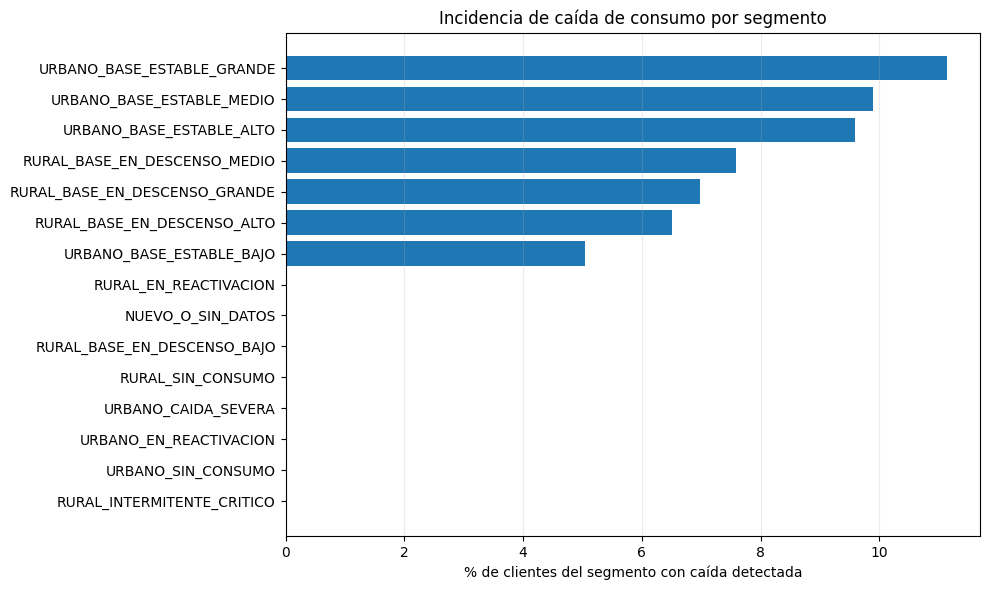

C:\Users\Home\AppData\Local\Temp\ipykernel_21588\1667906310.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_box, labels=segmentos_grandes, vert=True, showfliers=False)


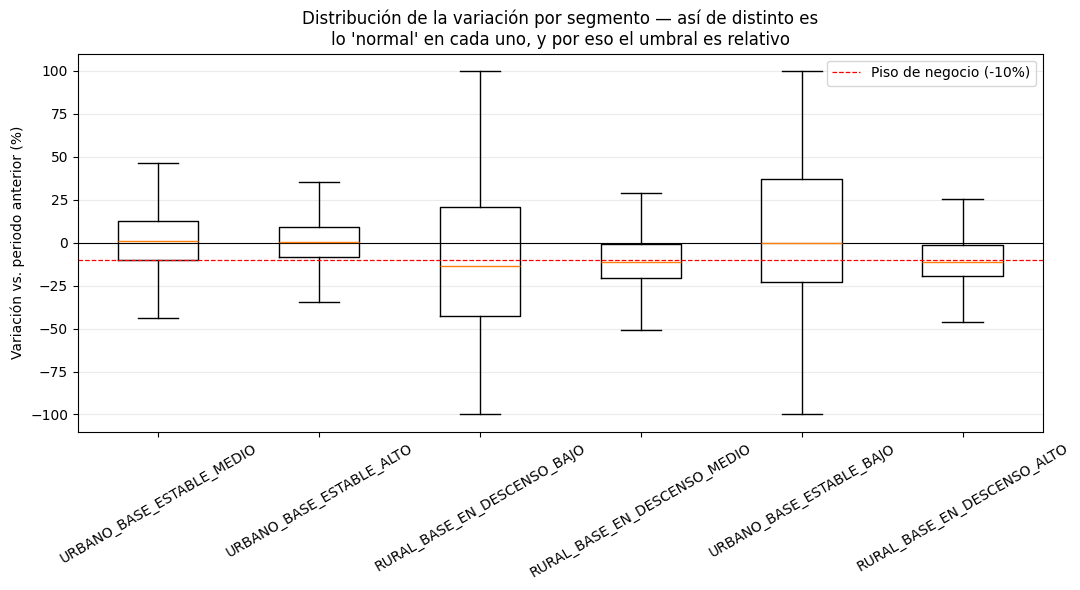

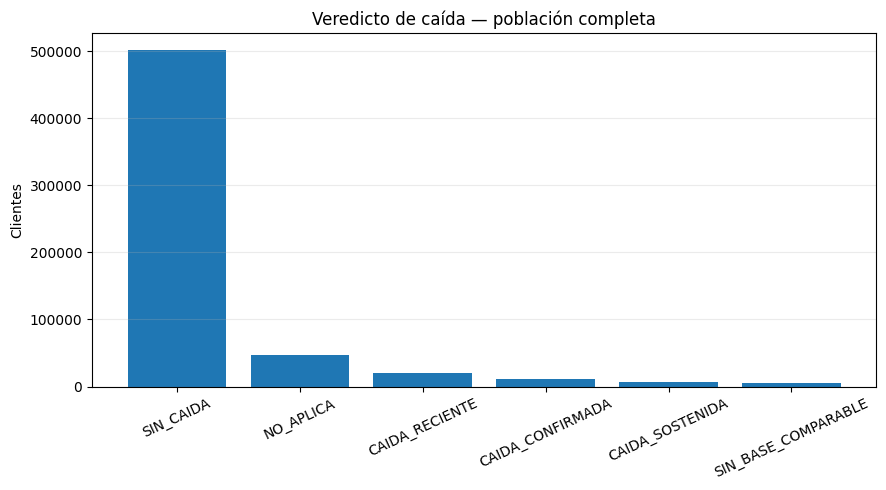

In [13]:
# ============================================================
# 13. GRÁFICAS
# ============================================================

# --- 1. % de clientes con caída por segmento ---
graf = resumen_segmento.sort_values("pct_con_caida", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(graf["cluster_id"], graf["pct_con_caida"])
ax.set_xlabel("% de clientes del segmento con caída detectada")
ax.set_title("Incidencia de caída de consumo por segmento")
ax.grid(alpha=0.25, axis="x")
plt.tight_layout()
plt.show()

# --- 2. Distribución de la variación en los segmentos masivos ---
segmentos_grandes = (
    resumen_segmento.nlargest(6, "n_clientes")["cluster_id"].tolist()
)

fig, ax = plt.subplots(figsize=(11, 6))
datos_box = [
    caida.loc[
        (caida["cluster_id"] == s)
        & caida["variacion_vs_anterior_pct"].notna(),
        "variacion_vs_anterior_pct",
    ].clip(-100, 100)
    for s in segmentos_grandes
]
ax.boxplot(datos_box, labels=segmentos_grandes, vert=True, showfliers=False)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(UMBRAL_MINIMO_CAIDA_PCT, color="red", linestyle="--", linewidth=0.9,
           label=f"Piso de negocio ({UMBRAL_MINIMO_CAIDA_PCT:.0f}%)")
ax.set_ylabel("Variación vs. periodo anterior (%)")
ax.set_title("Distribución de la variación por segmento — así de distinto es\n"
             "lo 'normal' en cada uno, y por eso el umbral es relativo")
ax.tick_params(axis="x", rotation=30)
ax.legend()
ax.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()

# --- 3. Composición de veredictos ---
fig, ax = plt.subplots(figsize=(9, 5))
conteo = caida["veredicto"].value_counts()
ax.bar(conteo.index, conteo.values)
ax.set_ylabel("Clientes")
ax.set_title("Veredicto de caída — población completa")
ax.tick_params(axis="x", rotation=25)
ax.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()


In [14]:
# ============================================================
# 14. CIERRE
# ============================================================

print("ESTUDIO DE CAÍDA DE CONSUMO — TERMINADO")
print("=" * 78)

print(f"\nPoblación evaluada : {len(caida):,} clientes")
print(f"Ventana mensual    : {MESES_VENTANA_MENSUAL} meses "
      f"({VENTANAS['MENSUAL']['reciente'][0]:%Y-%m} → "
      f"{VENTANAS['MENSUAL']['reciente'][-1]:%Y-%m})")
print(f"Ventana trimestral : {MESES_VENTANA_TRIMESTRAL} meses "
      f"({VENTANAS['TRIMESTRAL']['reciente'][0]:%Y-%m} → "
      f"{VENTANAS['TRIMESTRAL']['reciente'][-1]:%Y-%m})")

print("\nRESULTADO")
print("-" * 78)
for veredicto in ["CAIDA_CONFIRMADA", "CAIDA_SOSTENIDA", "CAIDA_RECIENTE"]:
    n = int((caida["veredicto"] == veredicto).sum())
    print(f"  {veredicto:<20}: {n:>7,} clientes")

print("\nSalidas:")
print(" •", RUTA_CAIDA, "(detalle por cliente)")
print(" •", RUTA_RESUMEN_SEGMENTO, "(tabla para negocio)")
print(" •", RUTA_PRIORITARIOS, "(lista accionable ordenada)")
print(" •", RUTA_DIAGNOSTICO_BORDE, "(diagnóstico del borde de la ventana)")


ESTUDIO DE CAÍDA DE CONSUMO — TERMINADO

Población evaluada : 592,159 clientes
Ventana mensual    : 3 meses (2025-11 → 2026-01)
Ventana trimestral : 6 meses (2025-08 → 2026-01)

RESULTADO
------------------------------------------------------------------------------
  CAIDA_CONFIRMADA    :  11,203 clientes
  CAIDA_SOSTENIDA     :   7,257 clientes
  CAIDA_RECIENTE      :  19,902 clientes

Salidas:
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\estudio_caida\estudio_caida_consumo.parquet (detalle por cliente)
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\estudio_caida\resumen_caida_por_segmento.csv (tabla para negocio)
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\estudio_caida\clientes_caida_prioritarios.csv (lista accionable ordenada)
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\estudio_caida\diagnostico_borde_ventana.csv (diagnóstico del borde de la ventana)
